# XBeach Stratigraphic Transects

This example loads XBeach morphodynamic model output, converts local `globalx`/`globaly` coordinates and bed level `zb` into the common `BathyCube` format, then sends that cube through `run_transect_slice_plots`, the same analysis/plotting workflow used for survey bathymetry.

Plan:
1. Load `xboutput.nc` with `load_xbeach_bathy_cube`.
2. Inspect the local grid, model time axis, and bed-level range.
3. Define editable transects in local XBeach x/y coordinates.
4. Plot transect locations on the final bed surface.
5. Run the common transect-slice workflow to extract 1D cubes, compute stratigraphy, and save stacked section plots.

In [ ]:
"""Import dependencies and ensure the local `code/` package directory is importable."""
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve the repository's `code` directory whether the notebook is launched from root or from `code/`.
code_dir = Path.cwd()
if code_dir.name != "code":
    code_dir = code_dir / "code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

from bathymetry_analysis import (
    Transect,
    load_xbeach_bathy_cube,
    median_grid_spacing,
    run_transect_slice_plots,
)
from bathymetry_analysis.stratigraphy import datenum_to_datetime64
from bathymetry_analysis.workflows import plot_transect_location_plan_from_transects
from utils.colormaps import bathymetry_colormap

## Configuration

XBeach `globaltime` is seconds since model start, so set `model_start_time` to the calendar date you want attached to the run. The stratigraphy calculation only needs ordered times; the absolute date is used for plot labels and optional highlighting.

In [ ]:
"""Set input paths, variable names, plotting limits, and output destinations."""
xbeach_nc = Path(r"C:\surf\650_SedTRAILS\xbeach\santa_rosa\run_s100\xboutput.nc")
output_root = Path("outputs") / "xbeach_santa_rosa_run_s100"
model_start_time = "2024-01-01 00:00:00"

# NetCDF variable names in xboutput.nc.
bed_var = "zb"
x_var = "globalx"
y_var = "globaly"
time_var = "globaltime"

# Shared plotting configuration for map and section outputs.
map_cmap, map_norm = bathymetry_colormap("SEAWAD", vmin=-20.0, vmax=10.0)
max_fig_width_cm = 20.0
max_fig_height_cm = 10.0
section_xlim = (0, 1000.0)
section_ylim = (-3.0, 3.0)

output_root.mkdir(parents=True, exist_ok=True)

## Load XBeach Output

In [ ]:
"""Load XBeach outputs into a BathyCube and summarize key grid/time metadata."""
cube = load_xbeach_bathy_cube(
    xbeach_nc,
    bed_var=bed_var,
    x_var=x_var,
    y_var=y_var,
    time_var=time_var,
    start_time=model_start_time,
    location="Santa Rosa XBeach run_s100",
)

# Estimate representative spacing from the 2D curvilinear grid.
dx, dy = median_grid_spacing(cube)

# Convert MATLAB-style datenums in the cube to display-friendly datetimes.
times = datenum_to_datetime64(cube.t)

summary = {
    "shape (ny, nx, nt)": cube.z.shape,
    "x range [m]": (float(np.nanmin(cube.x)), float(np.nanmax(cube.x))),
    "y range [m]": (float(np.nanmin(cube.y)), float(np.nanmax(cube.y))),
    "median dx [m]": dx,
    "median dy [m]": dy,
    "time range": (str(times[0]), str(times[-1])),
    "bed range [m]": (float(np.nanmin(cube.z)), float(np.nanmax(cube.z))),
}
summary

{'shape (ny, nx, nt)': (92, 178, 136),
 'x range [m]': (-39.116324400002895, 2464.5435016384363),
 'y range [m]': (-1350.000000000078, 3370.000000000078),
 'median dx [m]': 14.797900695160706,
 'median dy [m]': 60.0,
 'time range': ('2024-01-01T00:00:00.000000', '2024-01-01T04:30:00.000000'),
 'bed range [m]': (-20.003453791004002, 6.61447175)}

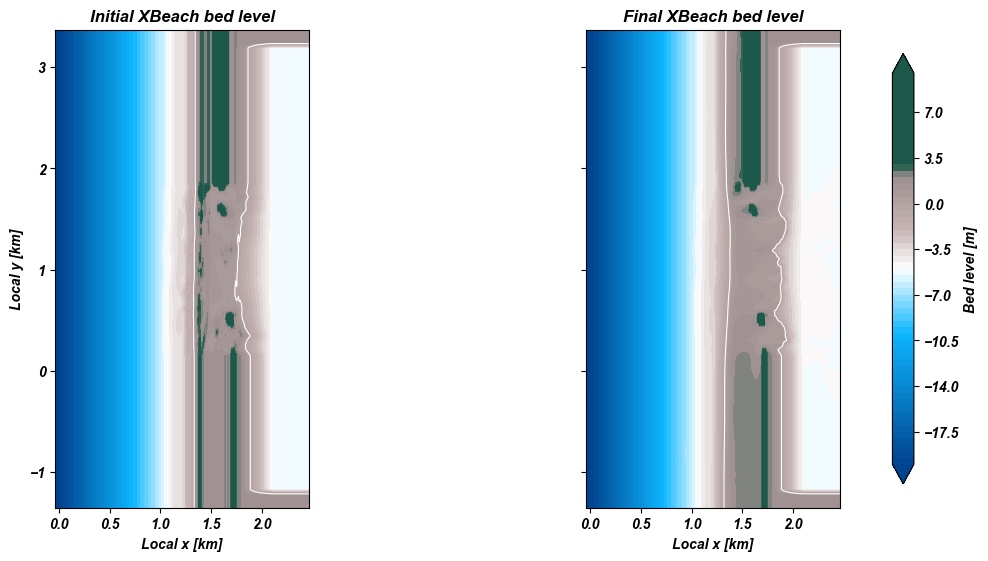

In [ ]:
"""Compare initial and final bed surfaces using a shared color scale."""
map_levels = np.linspace(-20.0, 10.0, 61)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, constrained_layout=True)
surfaces = [("Initial XBeach bed level", cube.z[:, :, 0]), ("Final XBeach bed level", cube.z[:, :, -1])]

cf = None
for ax, (title, surface) in zip(axes, surfaces):
    cf = ax.contourf(
        cube.x / 1000.0,
        cube.y / 1000.0,
        surface,
        levels=map_levels,
        cmap=map_cmap,
        norm=map_norm,
        extend="both",
    )
    # Overlay the still-water contour to orient shoreline position changes.
    ax.contour(cube.x / 1000.0, cube.y / 1000.0, surface, levels=[0.0], colors="w", linewidths=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Local x [km]")
    ax.set_title(title)
axes[0].set_ylabel("Local y [km]")
fig.colorbar(cf, ax=axes, label="Bed level [m]", shrink=0.9)

## Define Local-Coordinate Transects

The default transects run across the local `x` direction at three alongshore `y` positions. Edit `y_values` or replace `transects` with any `Transect(name, x, y)` list in local XBeach meters.

In [ ]:
"""Create three example cross-shore transects and preview their coordinates."""
# Use first row/column to infer 1D coordinate axes from the structured grid.
x_axis = cube.x[0, :]
y_axis = cube.y[:, 0]
x_min = float(np.nanmin(x_axis))
x_max = float(np.nanmax(x_axis))

# Place transects at quartile alongshore positions to sample variability.
y_values = np.quantile(y_axis, [0.25, 0.50, 0.75])

transects = [
    # Keep a fixed cross-shore span for direct comparison across alongshore transects.
    Transect(name=f"T{i + 1}", x=np.array([1000, 2000]), y=np.array([float(y_val), float(y_val)]))
    for i, y_val in enumerate(y_values)
]

# Workflow input uses [x0, y0, x1, y1] rows in kilometers.
transect_rows_km = np.array([[tr.x[0], tr.y[0], tr.x[-1], tr.y[-1]] for tr in transects], dtype=float) / 1000.0

pd.DataFrame(
    {
        "name": [tr.name for tr in transects],
        "x_start_m": [tr.x[0] for tr in transects],
        "x_end_m": [tr.x[-1] for tr in transects],
        "y_start_m": [tr.y[0] for tr in transects],
        "y_end_m": [tr.y[-1] for tr in transects],
    }
)

,name,x_start_m,x_end_m,y_start_m,y_end_m
0,T1,1000,2000,15.0,15.0
1,T2,1000,2000,1010.0,1010.0
2,T3,1000,2000,2005.0,2005.0


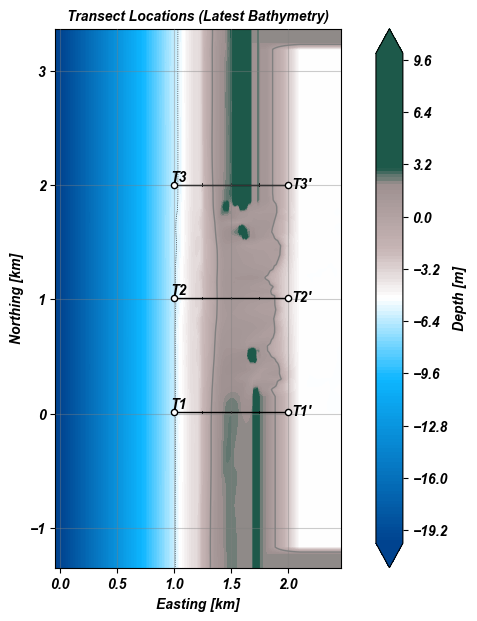

Saved transect plan to: outputs\xbeach_santa_rosa_run_s100\plots\python\stratigraphy\transect_slice\xbeach_transect_locations.png


WindowsPath('outputs/xbeach_santa_rosa_run_s100/plots/python/stratigraphy/transect_slice/xbeach_transect_locations.png')

In [ ]:
"""Plot transect locations on the final bathymetry map and save the figure."""
plan_path = plot_transect_location_plan_from_transects(
    cube,
    transects,
    output_root=output_root,
    labels=[tr.name for tr in transects],
    mlw=0.0,
    tick_spacing_m=250.0,
    cmap_name="SEAWAD",
    map_output_name="xbeach_transect_locations.png",
)
plan_path

## Run Common Transect-Slice Workflow

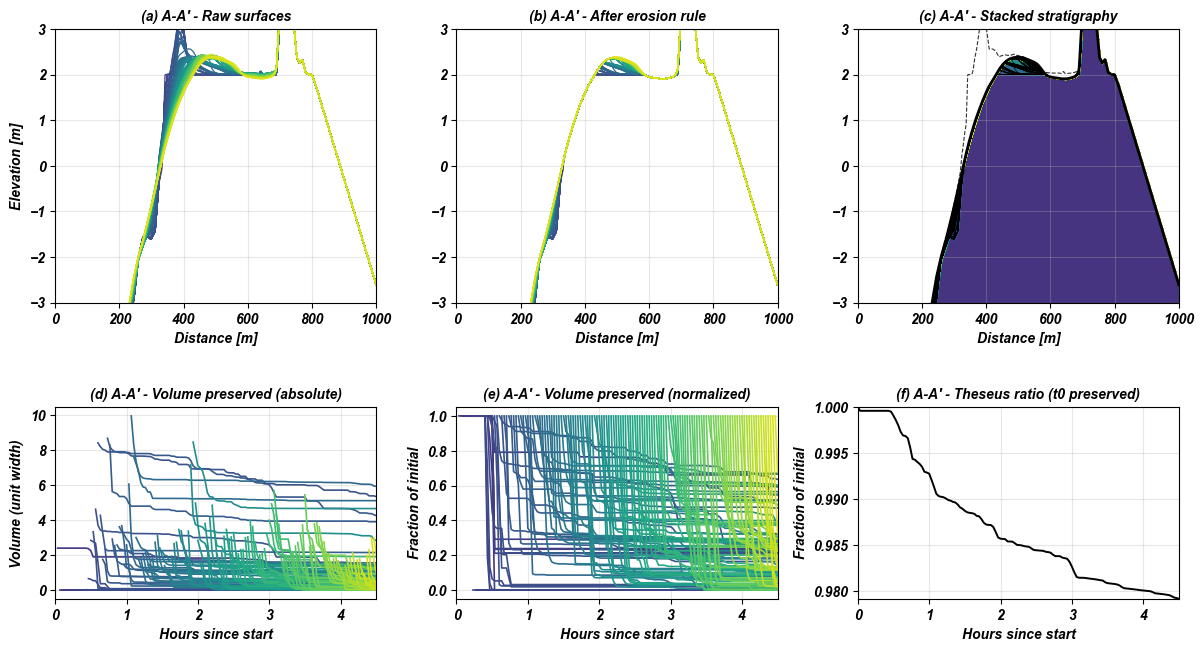

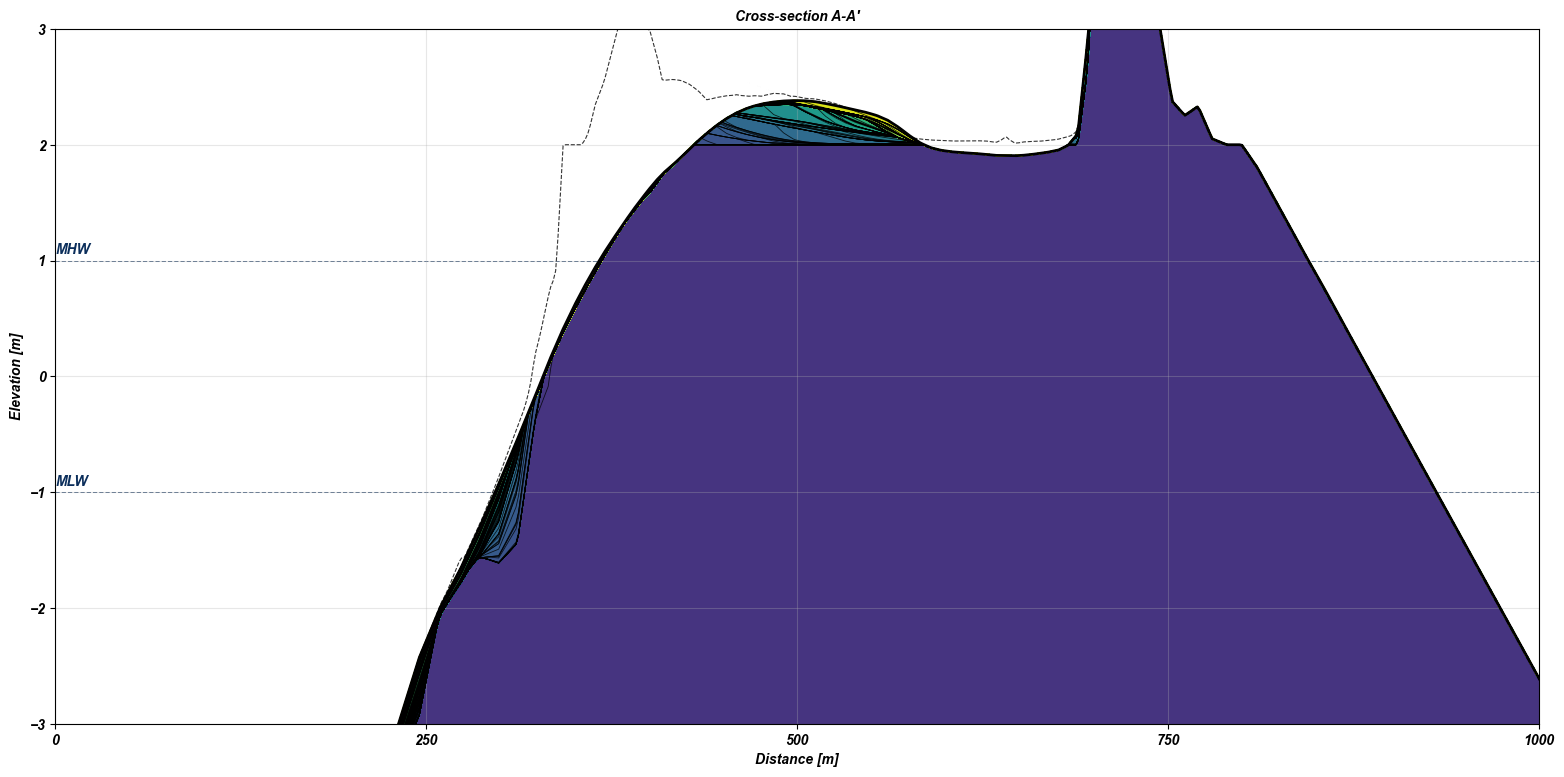

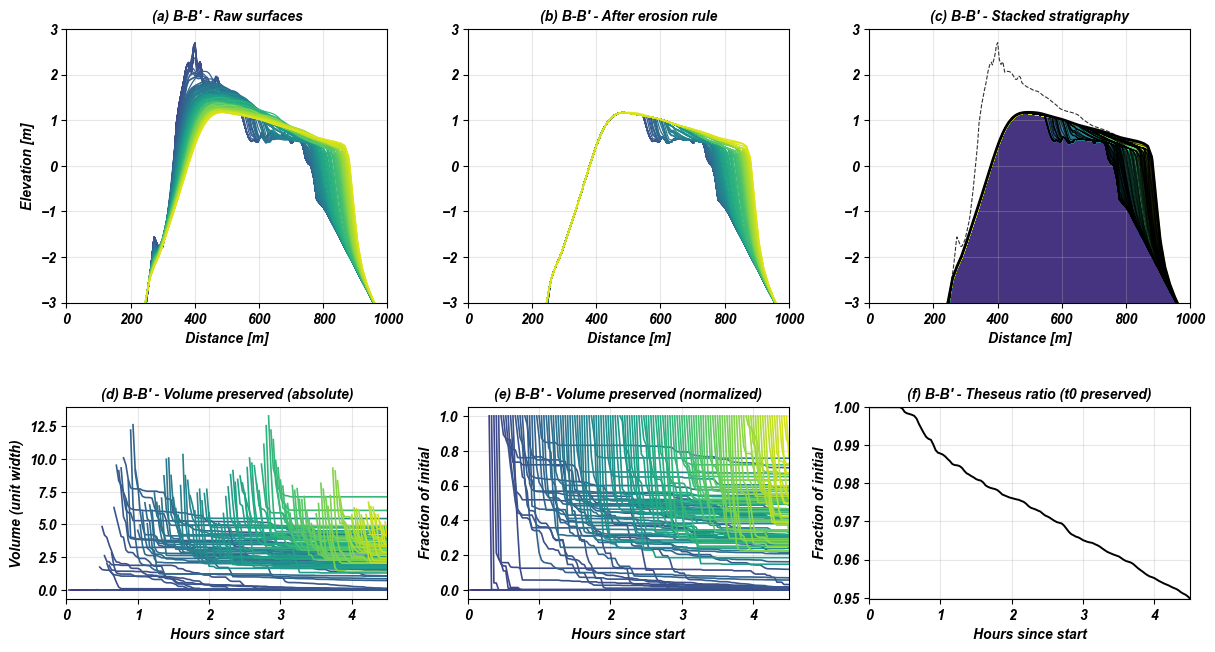

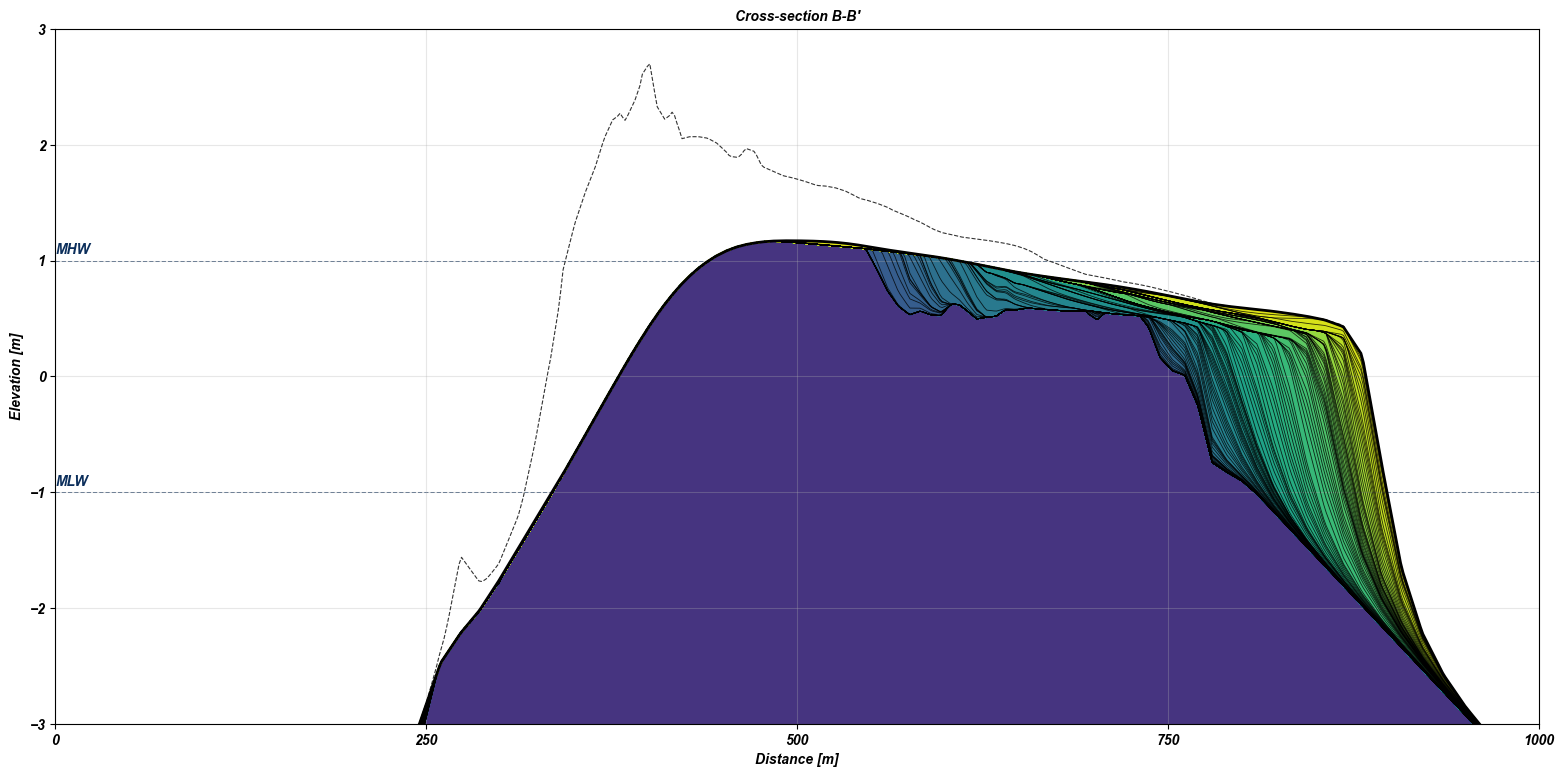

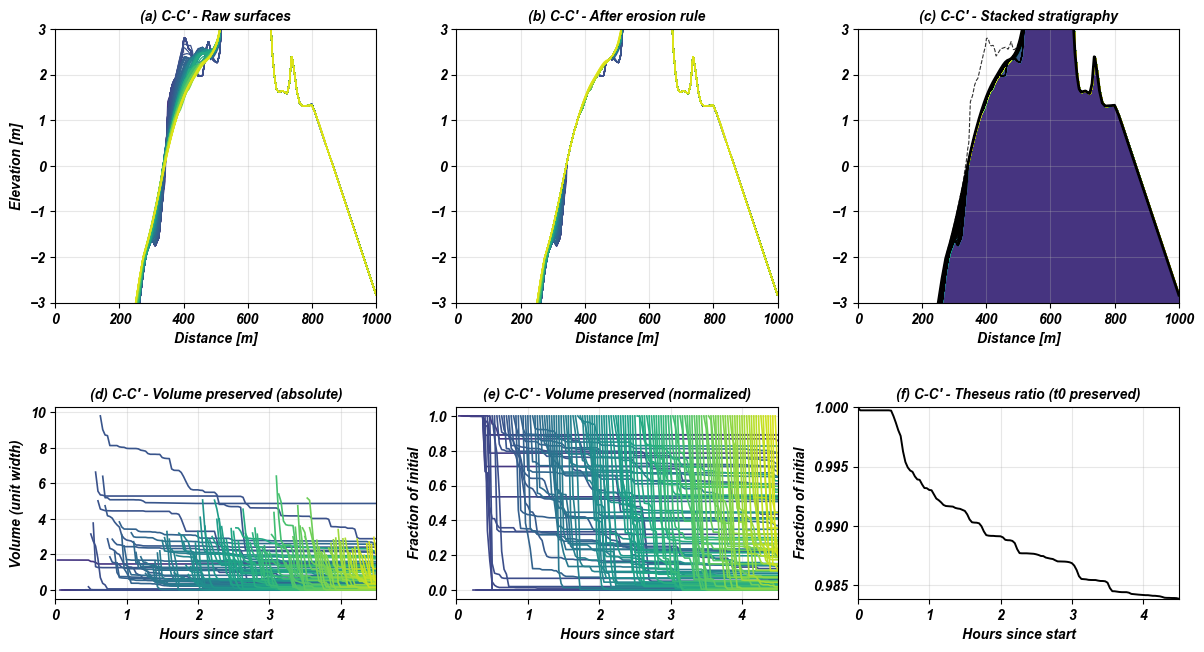

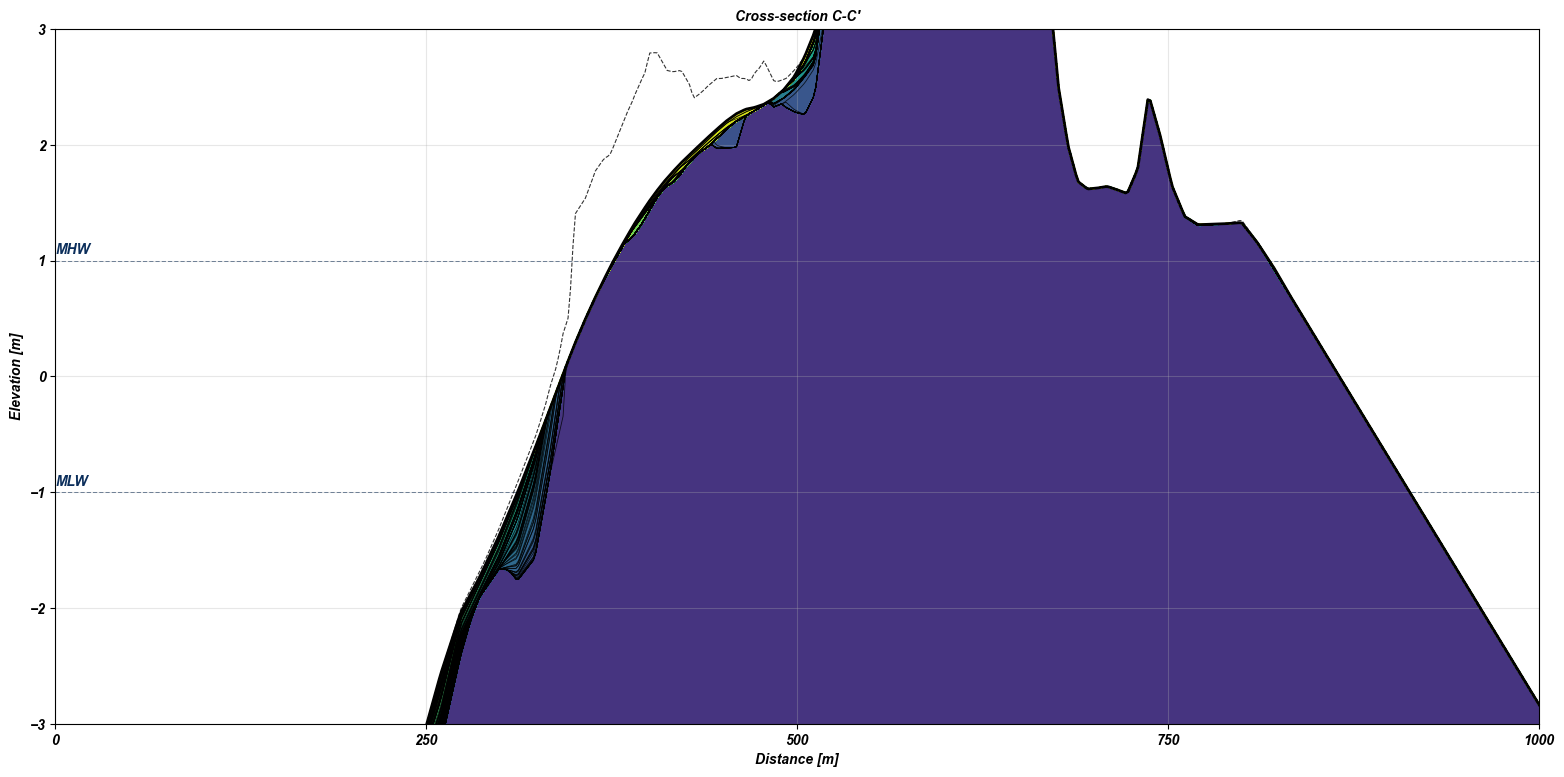

{'bathy_cube': BathyCube(location='Santa Rosa XBeach run_s100', t=array([739252.        , 739252.00138889, 739252.00277778, 739252.00416667,
        739252.00555556, 739252.00694444, 739252.00833333, 739252.00972222,
        739252.01111111, 739252.0125    , 739252.01388889, 739252.01527778,
        739252.01666667, 739252.01805556, 739252.01944444, 739252.02083333,
        739252.02222222, 739252.02361111, 739252.025     , 739252.02638889,
        739252.02777778, 739252.02916667, 739252.03055556, 739252.03194444,
        739252.03333333, 739252.03472222, 739252.03611111, 739252.0375    ,
        739252.03888889, 739252.04027778, 739252.04166667, 739252.04305556,
        739252.04444444, 739252.04583333, 739252.04722222, 739252.04861111,
        739252.05      , 739252.05138889, 739252.05277778, 739252.05416667,
        739252.05555556, 739252.05694444, 739252.05833333, 739252.05972222,
        739252.06111111, 739252.0625    , 739252.06388889, 739252.06527778,
        739252.06666667

In [ ]:
"""Run the shared transect-slice workflow to compute and plot stratigraphic sections."""
transect_outputs = run_transect_slice_plots(
    # The workflow accepts either a netCDF path or a preloaded BathyCube.
    bathy_nc_path=cube,
    output_root=output_root,
    transect_rows_km=transect_rows_km,
    tick_spacing_m=250.0,
    mhw=1.0,
    mlw=-1.0,
    n_points=600,
    initial_index=0,
    dx=None,
    max_fig_width_cm=max_fig_width_cm,
    max_fig_height_cm=max_fig_height_cm,
    plot_xlim=section_xlim,
    plot_ylim=section_ylim,
    clip_x_to_data=False,
    clip_y_to_data=False,
)
transect_outputs

In [ ]:
"""Print the root folder where transect-slice outputs were written."""
print(f"Saved outputs under: {transect_outputs['slice_dir'].resolve()}")